In [1]:
import pandas as pd

rfm = pd.read_csv("../data/processed/rfm_customer_data.csv")

rfm.shape

(5878, 8)

In [3]:
rfm.columns

Index(['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score',
       'M_Score', 'RFM_Score'],
      dtype='object')

In [4]:
from sklearn.preprocessing import StandardScaler

rfm_kmeans = rfm[["Recency", "Frequency", "Monetary"]]

rfm_kmeans.head()

,Recency,Frequency,Monetary
0,326,12,77556.46
1,2,8,5633.32
2,75,5,2019.40
3,19,4,4428.69
4,310,1,334.40


In [5]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_kmeans)

rfm_scaled[:5]

array([[ 0.59558355,  0.43899789,  5.05805027],
       [-0.95227909,  0.13150188,  0.17743068],
       [-0.60353226, -0.09912012, -0.06780567],
       [-0.87106408, -0.17599412,  0.09568591],
       [ 0.51914589, -0.40661612, -0.18214779]])

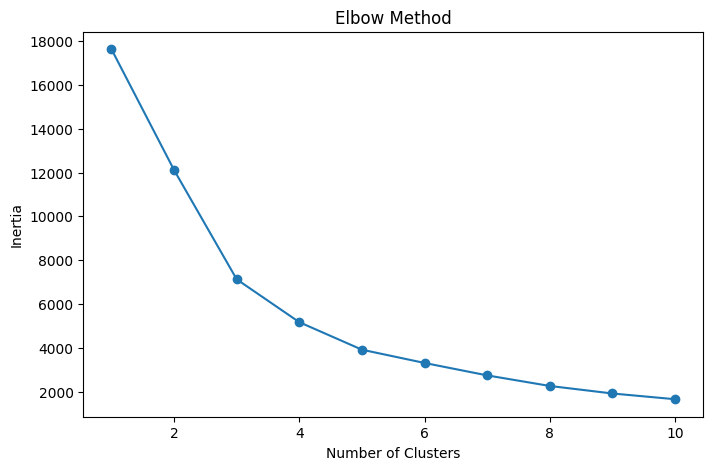

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster
0,12346.0,326,12,77556.46,2,5,5,255,1
1,12347.0,2,8,5633.32,5,4,5,545,1
2,12348.0,75,5,2019.40,3,4,4,344,1
3,12349.0,19,4,4428.69,5,3,5,535,1
4,12350.0,310,1,334.40,2,1,2,212,0


In [8]:
rfm["Cluster"].value_counts()

Cluster
1    3841
0    1998
2      35
3       4
Name: count, dtype: int64

In [9]:
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,463.032032,2.212212,765.244446
1,67.005728,7.307732,3009.402451
2,25.942857,103.714286,83086.079771
3,3.500000,212.500000,436835.792500


In [10]:
cluster_names = {
    0: "At-Risk",
    1: "Regular",
    2: "VIP",
    3: "Elite"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_names)

rfm[["Customer ID", "Cluster", "Segment"]].head()

,Customer ID,Cluster,Segment
0,12346.0,1,Regular
1,12347.0,1,Regular
2,12348.0,1,Regular
3,12349.0,1,Regular
4,12350.0,0,At-Risk


In [11]:
rfm["Segment"].value_counts()

Segment
Regular    3841
At-Risk    1998
VIP          35
Elite         4
Name: count, dtype: int64

In [12]:
rfm.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

print("Customer segmentation dataset saved successfully!")

Customer segmentation dataset saved successfully!
